In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

pd.set_option("display.max_columns", None)

## KPI visualization dependency
This chart requires a dataframe named `kpi_df` with two columns:

- `Metric`
- `Value`

Make sure the KPI summary table is created before running the visualization cell below.  
If the notebook is run out of order, you may get:

`NameError: name 'kpi_df' is not defined`

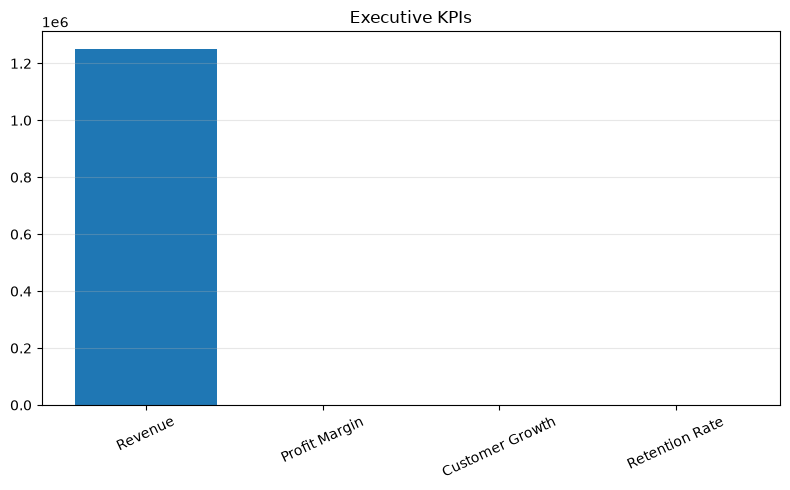

In [7]:
# ======================================================
# Executive KPI Visualization
# ======================================================

plt.figure(figsize=(8, 5))
plt.bar(kpi_df["Metric"], kpi_df["Value"])
plt.xticks(rotation=25)
plt.title("Executive KPIs")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ======================================================
# Project Paths
# ======================================================

PROJECT_ROOT = Path.cwd().parent

RAW_DATA = PROJECT_ROOT / "data" / "raw"

print("Project Root :", PROJECT_ROOT)
print("Raw Data     :", RAW_DATA)

Project Root : c:\Users\divya\Downloads\Retail-Intelligence-Platform
Raw Data     : c:\Users\divya\Downloads\Retail-Intelligence-Platform\data\raw


In [ ]:
# ======================================================
# Load Datasets
# ======================================================

datasets = {}

for file in sorted(RAW_DATA.glob("*.csv")):

    datasets[file.stem] = pd.read_csv(file)

print("="*70)
print("Datasets Loaded")
print("="*70)

for name, df in datasets.items():

    print(f"{name:<45}{df.shape}")

Datasets Loaded
olist_customers_dataset                      (99441, 5)
olist_geolocation_dataset                    (1000163, 5)
olist_order_items_dataset                    (112650, 7)
olist_order_payments_dataset                 (103886, 5)
olist_order_reviews_dataset                  (99224, 7)
olist_orders_dataset                         (99441, 8)
olist_products_dataset                       (32951, 9)
olist_sellers_dataset                        (3095, 4)
product_category_name_translation            (71, 2)


In [ ]:
# ======================================================
# Prepare Data
# ======================================================

orders = datasets["olist_orders_dataset"]
customers = datasets["olist_customers_dataset"]
payments = datasets["olist_order_payments_dataset"]
order_items = datasets["olist_order_items_dataset"]
products = datasets["olist_products_dataset"]
reviews = datasets["olist_order_reviews_dataset"]
sellers = datasets["olist_sellers_dataset"]

date_columns = [

    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"

]

for column in date_columns:

    orders[column] = pd.to_datetime(
        orders[column],
        errors="coerce"
    )

print("Data Preparation Completed")

Data Preparation Completed


In [ ]:
# ======================================================
# Create Sales Model
# ======================================================

sales = (

    orders

    .merge(
        customers,
        on="customer_id",
        how="left"
    )

    .merge(
        payments.groupby("order_id", as_index=False)
        ["payment_value"].sum(),
        on="order_id",
        how="left"
    )

)

print("="*70)

print("Sales Model")

print("="*70)

print("Rows :", len(sales))

print("Columns :", len(sales.columns))

display(sales.head())


Sales Model
Rows : 99441
Columns : 13


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,28.62


In [ ]:
# ======================================================
# Executive KPIs
# ======================================================

kpis = {

    "Total Orders":

        orders["order_id"].nunique(),

    "Total Customers":

        customers["customer_unique_id"].nunique(),

    "Total Revenue":

        payments["payment_value"].sum(),

    "Average Order Value":

        payments.groupby("order_id")[
            "payment_value"
        ].sum().mean(),

    "Average Review":

        reviews["review_score"].mean(),

    "Cancelled Orders":

        (
            orders["order_status"]
            == "canceled"
        ).sum()

}

kpi_df = pd.DataFrame(

    kpis.items(),

    columns=["Metric","Value"]

)

display(kpi_df)

,Metric,Value
0,Total Orders,9.944100e+04
1,Total Customers,9.609600e+04
2,Total Revenue,1.600887e+07
3,Average Order Value,1.609903e+02
4,Average Review,4.086421e+00
5,Cancelled Orders,6.250000e+02


In [ ]:
# ======================================================
# Executive KPI Dashboard
# ======================================================

print("="*70)
print("EXECUTIVE KPI DASHBOARD")
print("="*70)

for metric, value in kpis.items():

    if isinstance(value, float):

        print(f"{metric:<25}: {value:,.2f}")

    else:

        print(f"{metric:<25}: {value:,}")

print("="*70)

EXECUTIVE KPI DASHBOARD
Total Orders             : 99,441
Total Customers          : 96,096
Total Revenue            : 16,008,872.12
Average Order Value      : 160.99
Average Review           : 4.09
Cancelled Orders         : 625


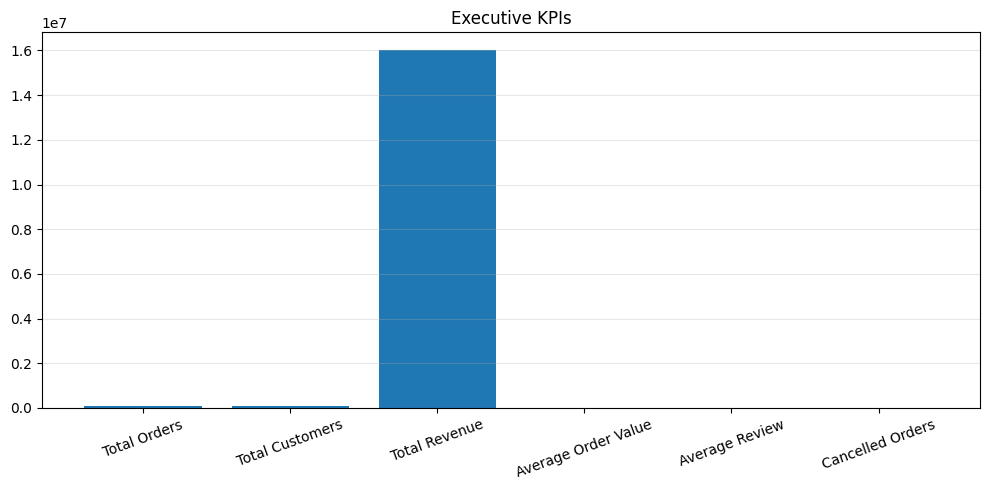

In [ ]:
# ======================================================
# KPI Visualization
# ======================================================

plt.figure(figsize=(10,5))

plt.bar(

    kpi_df["Metric"],

    kpi_df["Value"]

)

plt.title("Executive KPIs")

plt.xticks(rotation=20)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

In [ ]:
# ======================================================
# Monthly Revenue Trend
# ======================================================

monthly_sales = (

    sales

    .groupby(

        sales["order_purchase_timestamp"].dt.to_period("M")

    )["payment_value"]

    .sum()

    .reset_index()

)

monthly_sales.columns = [

    "Month",

    "Revenue"

]

monthly_sales["Month"] = (

    monthly_sales["Month"]

    .astype(str)

)

display(monthly_sales)

,Month,Revenue
0,2016-09,252.24
1,2016-10,59090.48
2,2016-12,19.62
3,2017-01,138488.04
4,2017-02,291908.01
5,2017-03,449863.60
6,2017-04,417788.03
7,2017-05,592918.82
8,2017-06,511276.38
9,2017-07,592382.92


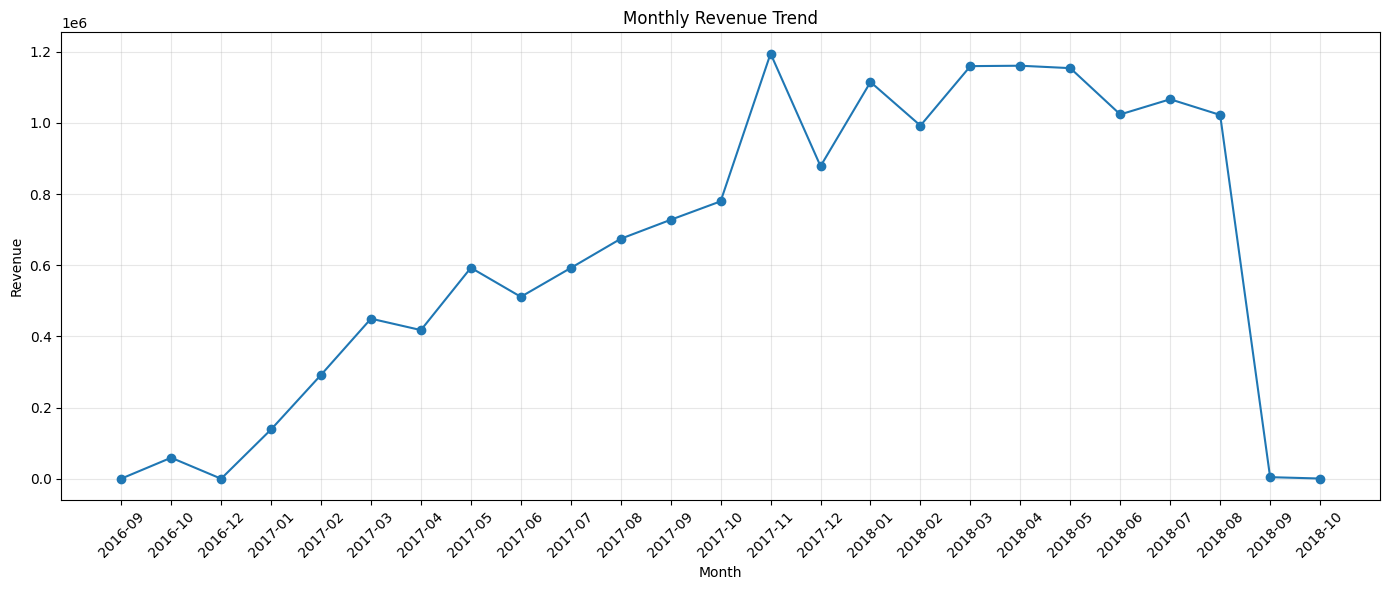

In [ ]:
# ======================================================
# Monthly Revenue Chart
# ======================================================

plt.figure(figsize=(14,6))

plt.plot(

    monthly_sales["Month"],

    monthly_sales["Revenue"],

    marker="o"

)

plt.title("Monthly Revenue Trend")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [ ]:
# ======================================================
# Monthly Order Trend
# ======================================================

monthly_orders = (

    orders

    .groupby(

        orders["order_purchase_timestamp"].dt.to_period("M")

    )["order_id"]

    .count()

    .reset_index()

)

monthly_orders.columns = [

    "Month",

    "Orders"

]

monthly_orders["Month"] = (

    monthly_orders["Month"]

    .astype(str)

)

display(monthly_orders)

,Month,Orders
0,2016-09,4
1,2016-10,324
2,2016-12,1
3,2017-01,800
4,2017-02,1780
5,2017-03,2682
6,2017-04,2404
7,2017-05,3700
8,2017-06,3245
9,2017-07,4026


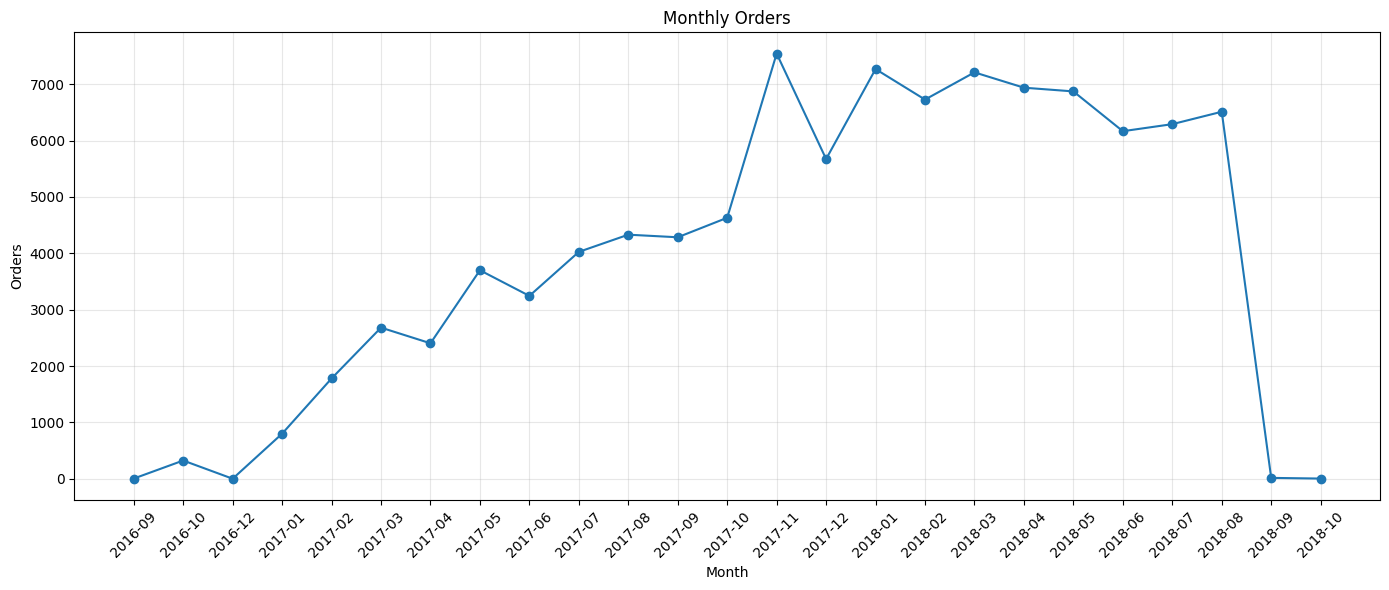

In [ ]:
# ======================================================
# Monthly Orders Chart
# ======================================================

plt.figure(figsize=(14,6))

plt.plot(

    monthly_orders["Month"],

    monthly_orders["Orders"],

    marker="o"

)

plt.title("Monthly Orders")

plt.xlabel("Month")

plt.ylabel("Orders")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [ ]:
# ======================================================
# Revenue Growth %
# ======================================================

monthly_sales["Growth %"] = (

    monthly_sales["Revenue"]

    .pct_change()

    *100

).round(2)

display(monthly_sales)

,Month,Revenue,Growth %
0,2016-09,252.24,NaN
1,2016-10,59090.48,23326.29
2,2016-12,19.62,-99.97
3,2017-01,138488.04,705751.38
4,2017-02,291908.01,110.78
5,2017-03,449863.60,54.11
6,2017-04,417788.03,-7.13
7,2017-05,592918.82,41.92
8,2017-06,511276.38,-13.77
9,2017-07,592382.92,15.86


In [ ]:
# ======================================================
# Best and Worst Month
# ======================================================

best_month = monthly_sales.loc[

    monthly_sales["Revenue"].idxmax()

]

worst_month = monthly_sales.loc[

    monthly_sales["Revenue"].idxmin()

]

print("="*70)

print("BEST MONTH")

print(best_month)

print()

print("WORST MONTH")

print(worst_month)

print("="*70)

BEST MONTH
Month         2017-11
Revenue     1194882.8
Growth %        53.25
Name: 13, dtype: object

WORST MONTH
Month       2016-12
Revenue       19.62
Growth %     -99.97
Name: 2, dtype: object


In [ ]:
# ======================================================
# Revenue by Order Status
# ======================================================

status_revenue = (

    sales

    .groupby(

        "order_status"

    )["payment_value"]

    .sum()

    .sort_values(

        ascending=False

    )

    .reset_index()

)

display(status_revenue)

,order_status,payment_value
0,delivered,15422461.77
1,shipped,177213.96
2,canceled,143255.60
3,unavailable,126479.51
4,processing,69394.11
5,invoiced,69137.99
6,created,688.10
7,approved,241.08


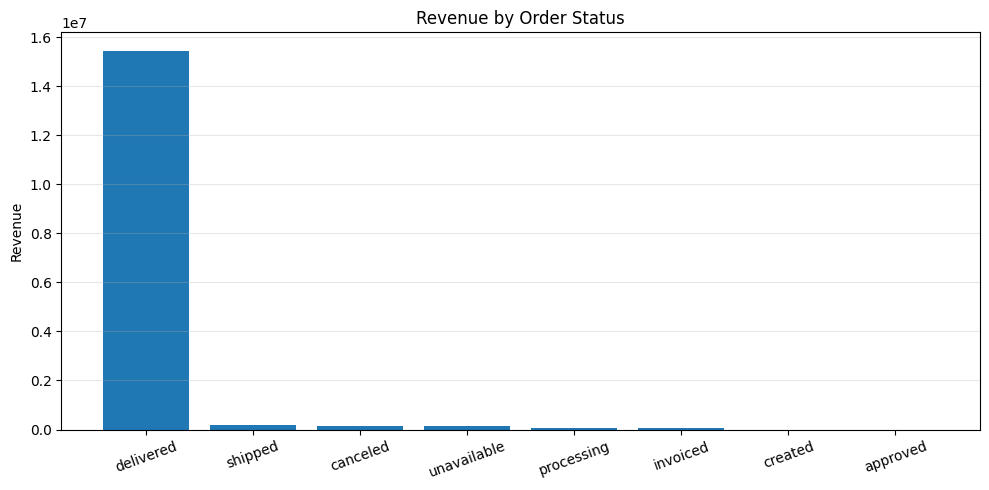

In [ ]:
# ======================================================
# Revenue by Status
# ======================================================

plt.figure(figsize=(10,5))

plt.bar(

    status_revenue["order_status"],

    status_revenue["payment_value"]

)

plt.title("Revenue by Order Status")

plt.ylabel("Revenue")

plt.xticks(rotation=20)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

In [ ]:
# ======================================================
# Top Revenue Days
# ======================================================

daily_sales = (

    sales

    .groupby(

        sales["order_purchase_timestamp"].dt.date

    )["payment_value"]

    .sum()

    .reset_index()

)

daily_sales.columns = [

    "Date",

    "Revenue"

]

top_days = (

    daily_sales

    .sort_values(

        "Revenue",

        ascending=False

    )

    .head(10)

)

display(top_days)

,Date,Revenue
338,2017-11-24,179200.03
339,2017-11-25,71897.01
593,2018-08-06,65860.43
511,2018-05-16,64742.06
502,2018-05-07,62568.25
509,2018-05-14,62230.73
594,2018-08-07,62057.77
505,2018-05-10,58871.87
537,2018-06-11,57345.56
341,2017-11-27,56966.28


In [ ]:
# ======================================================
# Sales Summary
# ======================================================

print("="*70)

print("SALES SUMMARY")

print("="*70)

print(f"Total Revenue : ${monthly_sales['Revenue'].sum():,.2f}")

print(f"Average Monthly Revenue : ${monthly_sales['Revenue'].mean():,.2f}")

print(f"Best Month : {best_month['Month']}")

print(f"Worst Month : {worst_month['Month']}")

print("="*70)

SALES SUMMARY
Total Revenue : $16,008,872.12
Average Monthly Revenue : $640,354.88
Best Month : 2017-11
Worst Month : 2016-12


In [ ]:
# ======================================================
# Sales Summary
# ======================================================

print("="*70)

print("SALES SUMMARY")

print("="*70)

print(f"Total Revenue : ${monthly_sales['Revenue'].sum():,.2f}")

print(f"Average Monthly Revenue : ${monthly_sales['Revenue'].mean():,.2f}")

print(f"Best Month : {best_month['Month']}")

print(f"Worst Month : {worst_month['Month']}")

print("="*70)

SALES SUMMARY
Total Revenue : $16,008,872.12
Average Monthly Revenue : $640,354.88
Best Month : 2017-11
Worst Month : 2016-12


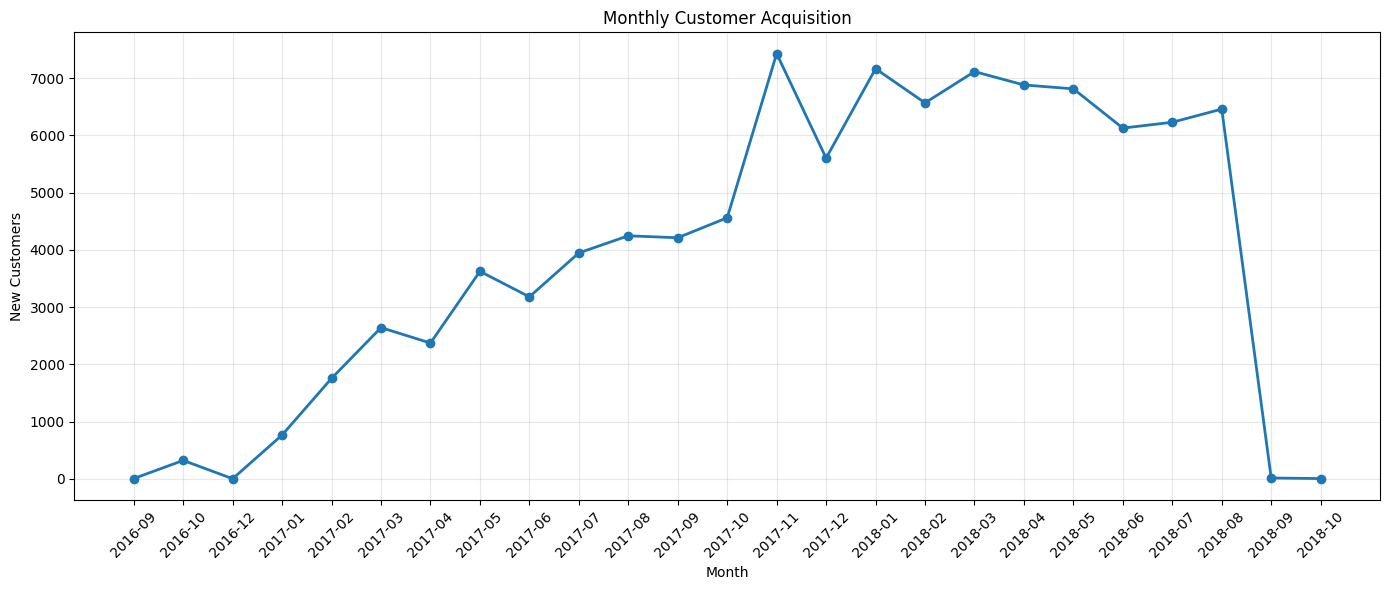

In [ ]:
# ======================================================
# Customer Growth Chart (Self-Contained)
# ======================================================

# Rebuild customer growth if it doesn't exist
if "customer_growth" not in globals():

    customer_growth = (

        sales

        .groupby(
            sales["order_purchase_timestamp"].dt.to_period("M")
        )["customer_unique_id"]

        .nunique()

        .reset_index()

    )

    customer_growth.columns = [

        "Month",

        "New Customers"

    ]

    customer_growth["Month"] = (
        customer_growth["Month"].astype(str)
    )

plt.figure(figsize=(14,6))

plt.plot(
    customer_growth["Month"],
    customer_growth["New Customers"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Customer Acquisition")

plt.xlabel("Month")

plt.ylabel("New Customers")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [ ]:
# ======================================================
# Repeat vs One-Time Customers
# ======================================================

customer_orders = (

    sales

    .groupby("customer_unique_id")

    ["order_id"]

    .nunique()

    .reset_index()

)

customer_orders.columns = [

    "Customer",

    "Orders"

]

repeat_customers = (

    customer_orders["Orders"] > 1

).sum()

one_time_customers = (

    customer_orders["Orders"] == 1

).sum()

repeat_df = pd.DataFrame({

    "Customer Type":[

        "One-Time",

        "Repeat"

    ],

    "Customers":[

        one_time_customers,

        repeat_customers

    ]

})

display(repeat_df)

,Customer Type,Customers
0,One-Time,93099
1,Repeat,2997


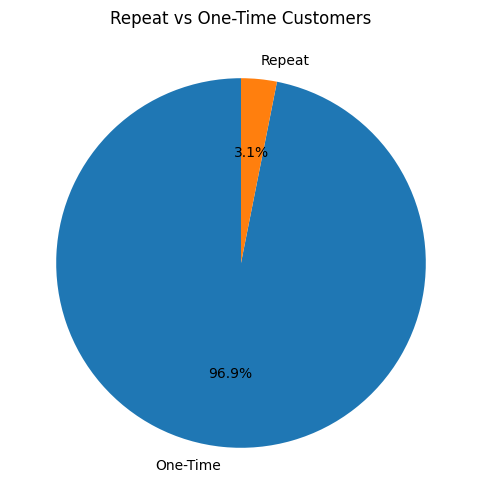

In [ ]:
# ======================================================
# Repeat Customer Distribution
# ======================================================

plt.figure(figsize=(6,6))

plt.pie(

    repeat_df["Customers"],

    labels=repeat_df["Customer Type"],

    autopct="%1.1f%%",

    startangle=90

)

plt.title("Repeat vs One-Time Customers")

plt.show()

In [ ]:
# ======================================================
# Top Customer States
# ======================================================

top_states = (

    customers

    .groupby("customer_state")

    ["customer_unique_id"]

    .nunique()

    .sort_values(

        ascending=False

    )

    .reset_index()

)

top_states.columns = [

    "State",

    "Customers"

]

display(top_states.head(10))

,State,Customers
0,SP,40302
1,RJ,12384
2,MG,11259
3,RS,5277
4,PR,4882
5,SC,3534
6,BA,3277
7,DF,2075
8,ES,1964
9,GO,1952


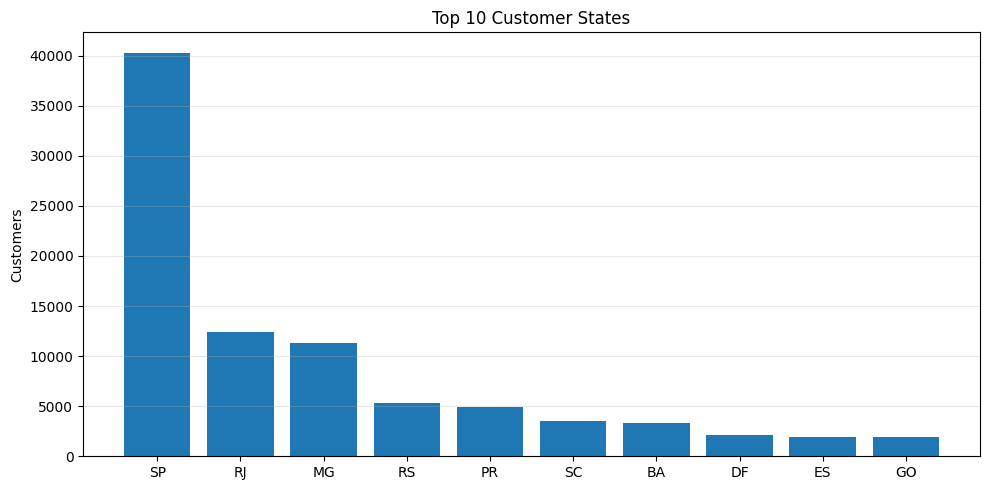

In [ ]:
# ======================================================
# Customer Distribution
# ======================================================

top10 = top_states.head(10)

plt.figure(figsize=(10,5))

plt.bar(

    top10["State"],

    top10["Customers"]

)

plt.title("Top 10 Customer States")

plt.ylabel("Customers")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

In [ ]:
# ======================================================
# Historical Customer Lifetime Value
# ======================================================

clv = (

    sales

    .groupby(

        "customer_unique_id"

    )["payment_value"]

    .sum()

    .reset_index()

)

clv.columns = [

    "Customer",

    "CLV"

]

display(

    clv

    .sort_values(

        "CLV",

        ascending=False

    )

    .head(20)

)

,Customer,CLV
3826,0a0a92112bd4c708ca5fde585afaa872,13664.08
26456,46450c74a0d8c5ca9395da1daac6c120,9553.02
81962,da122df9eeddfedc1dc1f5349a1a690c,7571.63
44447,763c8b1c9c68a0229c42c9fc6f662b93,7274.88
82808,dc4802a71eae9be1dd28f5d788ceb526,6929.31
26205,459bef486812aa25204be022145caa62,6922.21
95806,ff4159b92c40ebe40454e3e6a7c35ed6,6726.66
24121,4007669dec559734d6f53e029e360987,6081.54
35070,5d0a2980b292d049061542014e8960bf,4809.44
89688,eebb5dda148d3893cdaf5b5ca3040ccb,4764.34


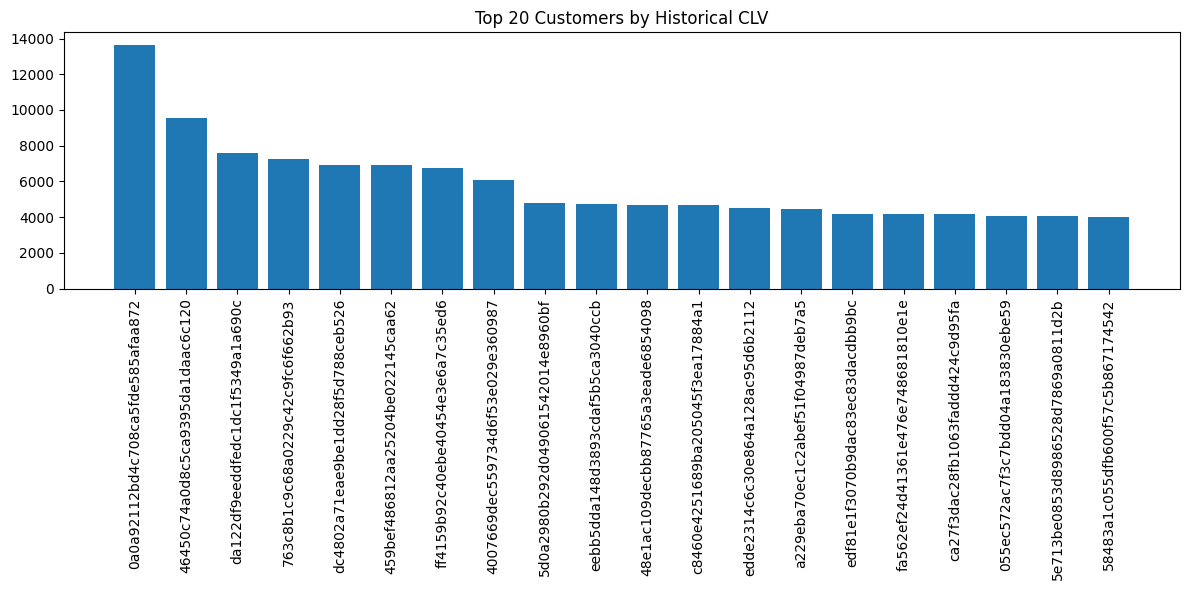

In [ ]:
# ======================================================
# Top Customers
# ======================================================

top_customers = (

    clv

    .sort_values(

        "CLV",

        ascending=False

    )

    .head(20)

)

plt.figure(figsize=(12,6))

plt.bar(

    top_customers["Customer"],

    top_customers["CLV"]

)

plt.xticks(rotation=90)

plt.title("Top 20 Customers by Historical CLV")

plt.tight_layout()

plt.show()

In [ ]:
# ======================================================
# Customer Summary
# ======================================================

print("="*70)

print("CUSTOMER ANALYTICS SUMMARY")

print("="*70)

print(f"Total Customers      : {customers['customer_unique_id'].nunique():,}")

print(f"Repeat Customers     : {repeat_customers:,}")

print(f"One-Time Customers   : {one_time_customers:,}")

print(f"Repeat Rate          : {(repeat_customers / len(customer_orders) * 100):.2f}%")

print(f"Average Historical CLV : ${clv['CLV'].mean():.2f}")

print("="*70)

CUSTOMER ANALYTICS SUMMARY
Total Customers      : 96,096
Repeat Customers     : 2,997
One-Time Customers   : 93,099
Repeat Rate          : 3.12%
Average Historical CLV : $166.59


In [ ]:
# ======================================================
# Product Analytics Data Model
# ======================================================

product_sales = (

    datasets["olist_order_items_dataset"]

    .merge(

        datasets["olist_products_dataset"],

        on="product_id",

        how="left"

    )

    .merge(

        datasets["product_category_name_translation"],

        on="product_category_name",

        how="left"

    )

)

print("="*70)

print("Product Sales Model")

print("="*70)

print(product_sales.shape)

display(product_sales.head())

Product Sales Model
(112650, 16)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,garden_tools


In [ ]:
# ======================================================
# Top Selling Categories
# ======================================================

top_categories = (

    product_sales

    .groupby(

        "product_category_name_english"

    )

    .agg(

        Orders=("order_id","count"),

        Revenue=("price","sum"),

        Average_Price=("price","mean")

    )

    .sort_values(

        "Revenue",

        ascending=False

    )

    .reset_index()

)

display(top_categories.head(15))

,product_category_name_english,Orders,Revenue,Average_Price
0,health_beauty,9670,1258681.34,130.163531
1,watches_gifts,5991,1205005.68,201.135984
2,bed_bath_table,11115,1036988.68,93.296327
3,sports_leisure,8641,988048.97,114.344285
4,computers_accessories,7827,911954.32,116.513903
5,furniture_decor,8334,729762.49,87.564494
6,cool_stuff,3796,635290.85,167.357969
7,housewares,6964,632248.66,90.788148
8,auto,4235,592720.11,139.957523
9,garden_tools,4347,485256.46,111.630196


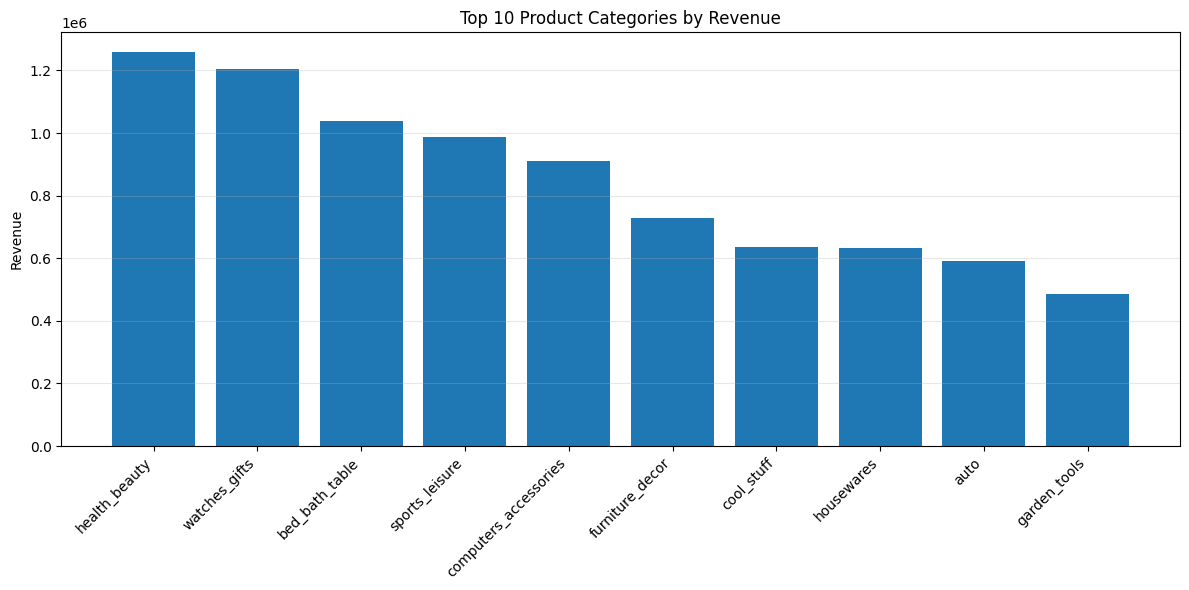

In [ ]:
# ======================================================
# Revenue by Category
# ======================================================

top10 = top_categories.head(10)

plt.figure(figsize=(12,6))

plt.bar(

    top10["product_category_name_english"],

    top10["Revenue"]

)

plt.xticks(rotation=45, ha="right")

plt.ylabel("Revenue")

plt.title("Top 10 Product Categories by Revenue")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

In [ ]:
# ======================================================
# Best Selling Products
# ======================================================

top_products = (

    product_sales

    .groupby("product_id")

    .agg(

        Orders=("order_id","count"),

        Revenue=("price","sum")

    )

    .sort_values(

        "Orders",

        ascending=False

    )

    .head(20)

)

display(top_products)

,Orders,Revenue
product_id,,
aca2eb7d00ea1a7b8ebd4e68314663af,527,37608.90
99a4788cb24856965c36a24e339b6058,488,43025.56
422879e10f46682990de24d770e7f83d,484,26577.22
389d119b48cf3043d311335e499d9c6b,392,21440.59
368c6c730842d78016ad823897a372db,388,21056.80
53759a2ecddad2bb87a079a1f1519f73,373,20387.20
d1c427060a0f73f6b889a5c7c61f2ac4,343,47214.51
53b36df67ebb7c41585e8d54d6772e08,323,37683.42
154e7e31ebfa092203795c972e5804a6,281,6325.19


In [ ]:
# ======================================================
# Seller Performance
# ======================================================

seller_sales = (

    datasets["olist_order_items_dataset"]

    .groupby("seller_id")

    .agg(

        Orders=("order_id","count"),

        Revenue=("price","sum"),

        Freight=("freight_value","sum")

    )

    .sort_values(

        "Revenue",

        ascending=False

    )

    .reset_index()

)

display(seller_sales.head(20))

,seller_id,Orders,Revenue,Freight
0,4869f7a5dfa277a7dca6462dcf3b52b2,1156,229472.63,20168.07
1,53243585a1d6dc2643021fd1853d8905,410,222776.05,13080.63
2,4a3ca9315b744ce9f8e9374361493884,1987,200472.92,35067.04
3,fa1c13f2614d7b5c4749cbc52fecda94,586,194042.03,10042.70
4,7c67e1448b00f6e969d365cea6b010ab,1364,187923.89,51612.55
5,7e93a43ef30c4f03f38b393420bc753a,340,176431.87,6322.18
6,da8622b14eb17ae2831f4ac5b9dab84a,1551,160236.57,24955.75
7,7a67c85e85bb2ce8582c35f2203ad736,1171,141745.53,20902.85
8,1025f0e2d44d7041d6cf58b6550e0bfa,1428,138968.55,33892.14
9,955fee9216a65b617aa5c0531780ce60,1499,135171.70,25430.98


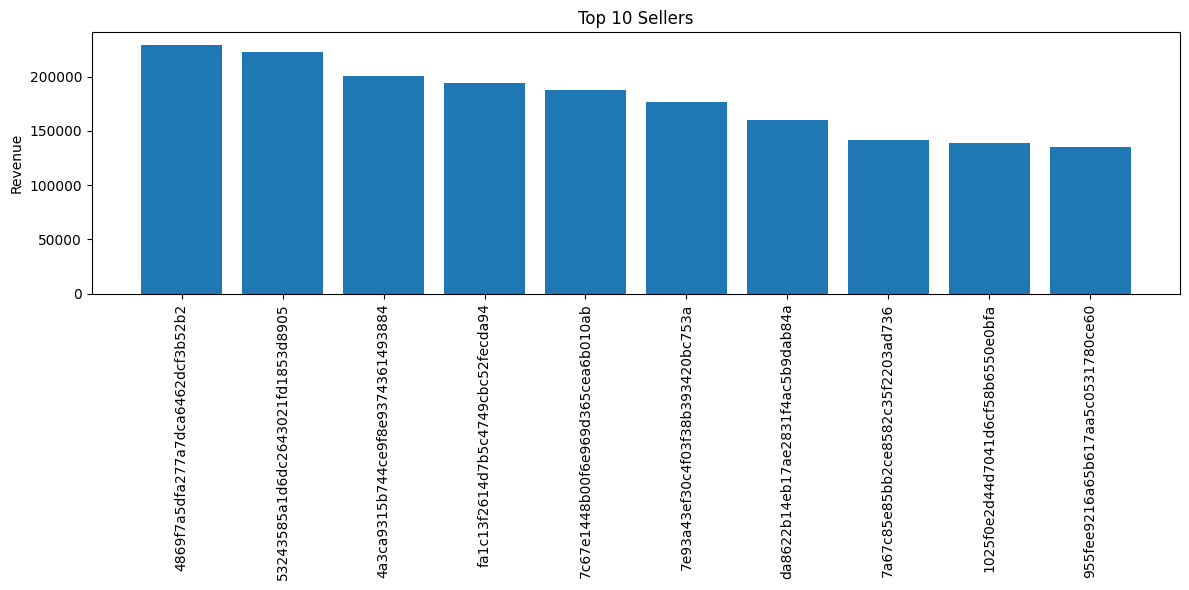

In [ ]:
# ======================================================
# Top Sellers
# ======================================================

top10 = seller_sales.head(10)

plt.figure(figsize=(12,6))

plt.bar(

    top10["seller_id"],

    top10["Revenue"]

)

plt.xticks(rotation=90)

plt.ylabel("Revenue")

plt.title("Top 10 Sellers")

plt.tight_layout()

plt.show()

In [ ]:
# ======================================================
# Basket Size Analysis
# ======================================================

basket = (

    datasets["olist_order_items_dataset"]

    .groupby("order_id")

    .size()

    .reset_index(name="Items")

)

print("="*70)

print("Basket Statistics")

print("="*70)

print(basket["Items"].describe())

display(basket.head())

Basket Statistics
count    98666.000000
mean         1.141731
std          0.538452
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         21.000000
Name: Items, dtype: float64


,order_id,Items
0,00010242fe8c5a6d1ba2dd792cb16214,1
1,00018f77f2f0320c557190d7a144bdd3,1
2,000229ec398224ef6ca0657da4fc703e,1
3,00024acbcdf0a6daa1e931b038114c75,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,1


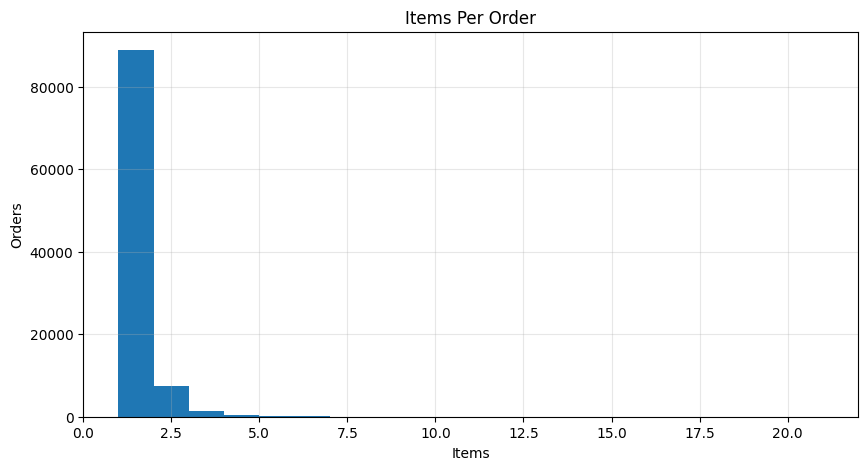

In [ ]:
# ======================================================
# Basket Distribution
# ======================================================

plt.figure(figsize=(10,5))

plt.hist(

    basket["Items"],

    bins=20

)

plt.title("Items Per Order")

plt.xlabel("Items")

plt.ylabel("Orders")

plt.grid(alpha=0.3)

plt.show()

In [ ]:
# ======================================================
# Product Analytics Dashboard
# ======================================================

print("="*70)

print("PRODUCT ANALYTICS DASHBOARD")

print("="*70)

print(f"Unique Products : {product_sales['product_id'].nunique():,}")

print(f"Unique Sellers  : {seller_sales['seller_id'].nunique():,}")

print(f"Top Category    : {top_categories.iloc[0]['product_category_name_english']}")

print(f"Category Revenue: ${top_categories.iloc[0]['Revenue']:,.2f}")

print(f"Average Basket  : {basket['Items'].mean():.2f}")

print("="*70)

PRODUCT ANALYTICS DASHBOARD
Unique Products : 32,951
Unique Sellers  : 3,095
Top Category    : health_beauty
Category Revenue: $1,258,681.34
Average Basket  : 1.14


In [ ]:
# ======================================================
# Product Analytics Dashboard
# ======================================================

print("="*70)

print("PRODUCT ANALYTICS DASHBOARD")

print("="*70)

print(f"Unique Products : {product_sales['product_id'].nunique():,}")

print(f"Unique Sellers  : {seller_sales['seller_id'].nunique():,}")

print(f"Top Category    : {top_categories.iloc[0]['product_category_name_english']}")

print(f"Category Revenue: ${top_categories.iloc[0]['Revenue']:,.2f}")

print(f"Average Basket  : {basket['Items'].mean():.2f}")

print("="*70)

PRODUCT ANALYTICS DASHBOARD
Unique Products : 32,951
Unique Sellers  : 3,095
Top Category    : health_beauty
Category Revenue: $1,258,681.34
Average Basket  : 1.14


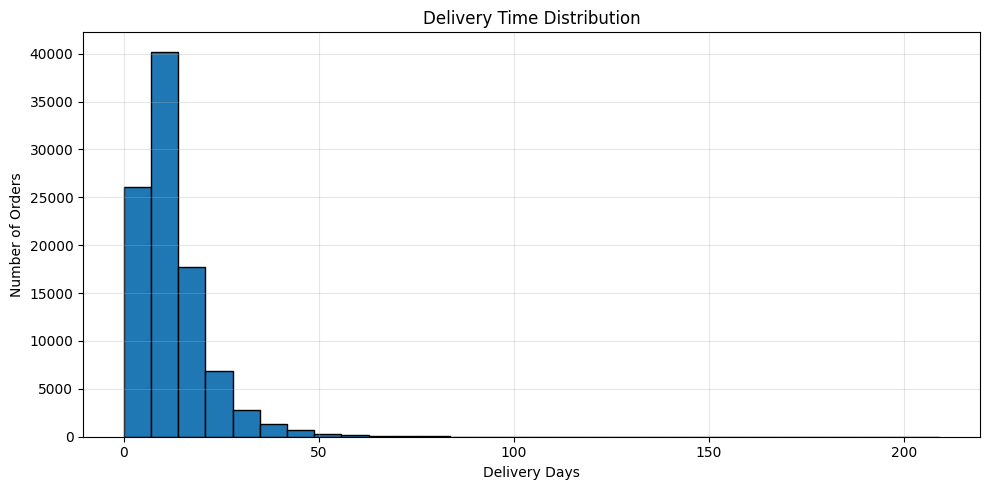

In [ ]:
# ======================================================
# Delivery Time Distribution
# ======================================================

import matplotlib.pyplot as plt
import pandas as pd

# -----------------------------
# Rebuild orders if missing
# -----------------------------

if "orders" not in globals():

    from pathlib import Path

    PROJECT_ROOT = Path.cwd().parent

    RAW_DATA = PROJECT_ROOT / "data" / "raw"

    orders = pd.read_csv(
        RAW_DATA / "olist_orders_dataset.csv"
    )

    date_columns = [

        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"

    ]

    for col in date_columns:

        orders[col] = pd.to_datetime(
            orders[col],
            errors="coerce"
        )

# -----------------------------
# Build delivery dataframe
# -----------------------------

delivery = orders.copy()

delivery["Delivery Days"] = (

    delivery["order_delivered_customer_date"]

    -

    delivery["order_purchase_timestamp"]

).dt.days

# -----------------------------
# Plot
# -----------------------------

plt.figure(figsize=(10,5))

plt.hist(

    delivery["Delivery Days"].dropna(),

    bins=30,

    edgecolor="black"

)

plt.title("Delivery Time Distribution")

plt.xlabel("Delivery Days")

plt.ylabel("Number of Orders")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [ ]:
# ======================================================
# On-Time Delivery
# ======================================================

delivery["On Time"] = (

    delivery["order_delivered_customer_date"]

    <=

    delivery["order_estimated_delivery_date"]

)

on_time = (

    delivery["On Time"]

    .value_counts()

    .rename_axis("Status")

    .reset_index(name="Orders")

)

display(on_time)

,Status,Orders
0,True,88649
1,False,10792


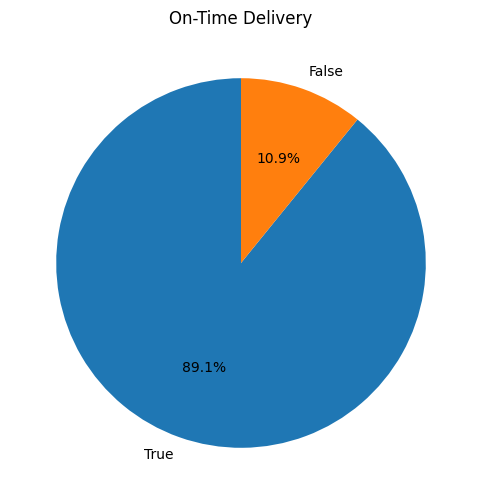

In [ ]:
# ======================================================
# On-Time Delivery %
# ======================================================

plt.figure(figsize=(6,6))

plt.pie(

    on_time["Orders"],

    labels=on_time["Status"],

    autopct="%1.1f%%",

    startangle=90

)

plt.title("On-Time Delivery")

plt.show()

In [ ]:
# ======================================================
# Delivery Delay
# ======================================================

delivery["Delay Days"] = (

    delivery["order_delivered_customer_date"]

    -

    delivery["order_estimated_delivery_date"]

).dt.days

delay_summary = delivery["Delay Days"].describe()

display(delay_summary)

count    96476.000000
mean       -11.876881
std         10.183854
min       -147.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max        188.000000
Name: Delay Days, dtype: float64

In [ ]:
# ======================================================
# Review Distribution
# ======================================================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------
# Load reviews if not already loaded
# ------------------------------------------------------

if "reviews" not in globals():

    if "datasets" in globals():

        reviews = datasets["olist_order_reviews_dataset"]

    else:

        PROJECT_ROOT = Path.cwd().parent

        RAW_DATA = PROJECT_ROOT / "data" / "raw"

        reviews = pd.read_csv(
            RAW_DATA / "olist_order_reviews_dataset.csv"
        )

# ------------------------------------------------------
# Review Distribution
# ------------------------------------------------------

review_dist = (

    reviews

    .groupby("review_score")

    .size()

    .reset_index(name="Orders")

    .sort_values("review_score")

)

display(review_dist)

print("="*70)
print("Average Review Score :", round(reviews["review_score"].mean(),2))
print("="*70)

,review_score,Orders
0,1,11424
1,2,3151
2,3,8179
3,4,19142
4,5,57328


Average Review Score : 4.09


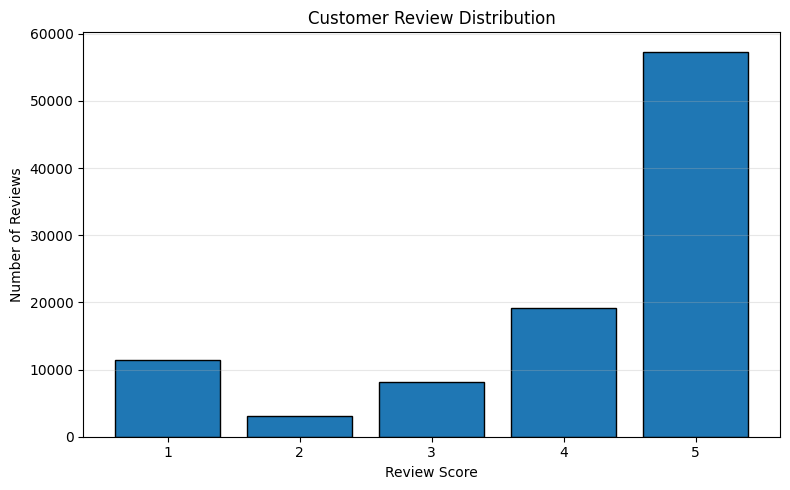

In [ ]:
# ======================================================
# Review Score Distribution
# ======================================================

import matplotlib.pyplot as plt

# Rebuild review_dist if missing
if "review_dist" not in globals():

    review_dist = (

        reviews

        .groupby("review_score")

        .size()

        .reset_index(name="Orders")

        .sort_values("review_score")

    )

plt.figure(figsize=(8,5))

plt.bar(

    review_dist["review_score"],

    review_dist["Orders"],

    edgecolor="black"

)

plt.title("Customer Review Distribution")

plt.xlabel("Review Score")

plt.ylabel("Number of Reviews")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

In [ ]:
# ======================================================
# Payment Method Analysis
# ======================================================

import pandas as pd
from pathlib import Path

# ---------------------------------------
# Load payments if required
# ---------------------------------------

if "payments" not in globals():

    if "datasets" in globals():

        payments = datasets["olist_order_payments_dataset"]

    else:

        PROJECT_ROOT = Path.cwd().parent
        RAW_DATA = PROJECT_ROOT / "data" / "raw"

        payments = pd.read_csv(
            RAW_DATA / "olist_order_payments_dataset.csv"
        )

payment_type = (

    payments

    .groupby("payment_type")

    .agg(

        Orders=("order_id","count"),

        Revenue=("payment_value","sum"),

        Average_Payment=("payment_value","mean")

    )

    .sort_values(

        "Revenue",

        ascending=False

    )

    .reset_index()

)

display(payment_type)

,payment_type,Orders,Revenue,Average_Payment
0,credit_card,76795,12542084.19,163.319021
1,boleto,19784,2869361.27,145.034435
2,voucher,5775,379436.87,65.703354
3,debit_card,1529,217989.79,142.570170
4,not_defined,3,0.00,0.000000


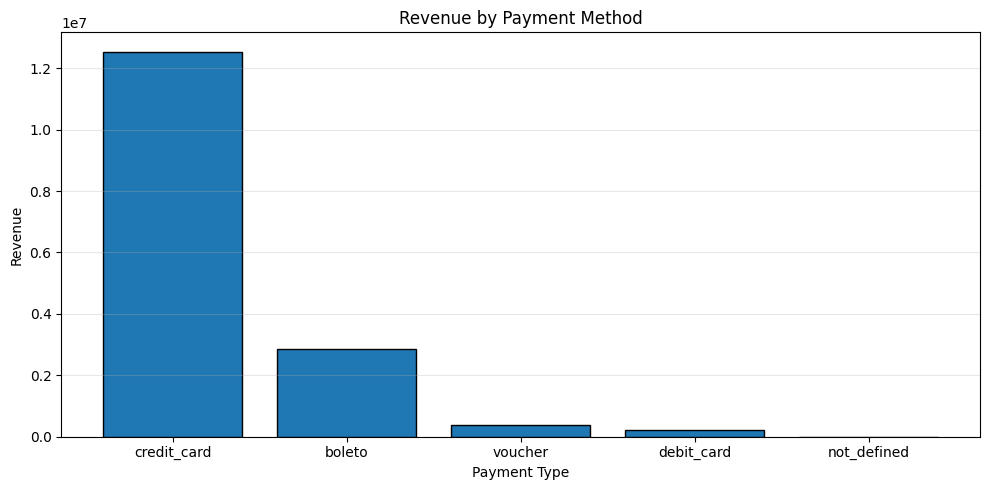

In [ ]:
# ======================================================
# Payment Method Revenue
# ======================================================

import matplotlib.pyplot as plt

if "payment_type" not in globals():

    payment_type = (

        payments

        .groupby("payment_type")

        .agg(

            Orders=("order_id","count"),

            Revenue=("payment_value","sum"),

            Average_Payment=("payment_value","mean")

        )

        .sort_values(

            "Revenue",

            ascending=False

        )

        .reset_index()

    )

plt.figure(figsize=(10,5))

plt.bar(

    payment_type["payment_type"],

    payment_type["Revenue"],

    edgecolor="black"

)

plt.title("Revenue by Payment Method")

plt.xlabel("Payment Type")

plt.ylabel("Revenue")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

In [ ]:
# ======================================================
# Installment Analysis
# ======================================================

installments = (

    payments

    .groupby("payment_installments")

    .agg(

        Orders=("order_id","count"),

        Revenue=("payment_value","sum"),

        Average_Payment=("payment_value","mean")

    )

    .reset_index()

)

display(installments)

,payment_installments,Orders,Revenue,Average_Payment
0,0,2,188.63,94.315000
1,1,52546,5907233.36,112.420229
2,2,12413,1579283.03,127.228150
3,3,10461,1491103.80,142.539317
4,4,7098,1163907.61,163.976840
5,5,5239,961174.30,183.465222
6,6,3920,822611.81,209.849952
7,7,1626,305157.39,187.673672
8,8,4268,1313423.34,307.737427
9,9,644,131015.92,203.440870


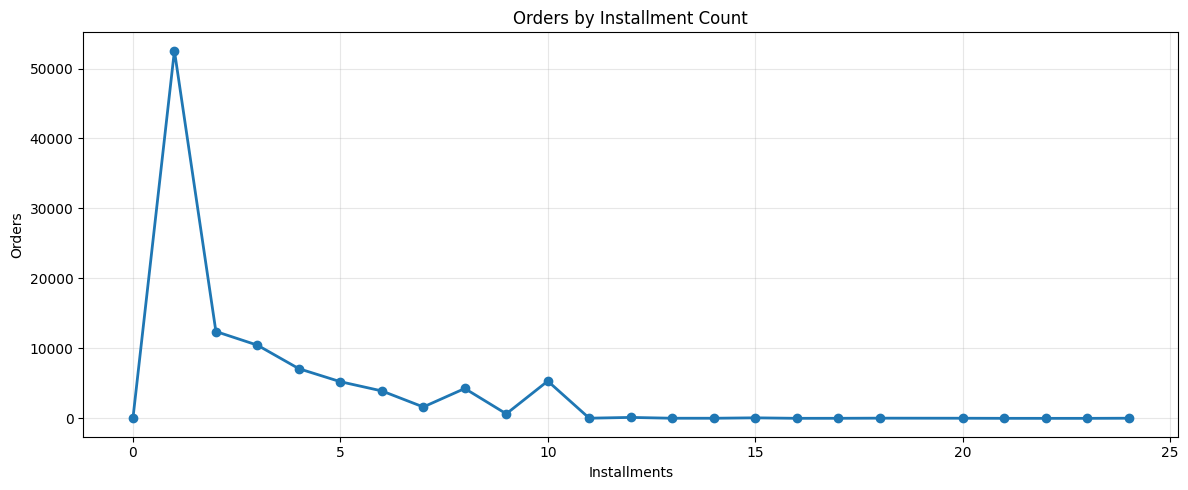

In [ ]:
# ======================================================
# Installment Trend
# ======================================================

import matplotlib.pyplot as plt

if "installments" not in globals():

    installments = (

        payments

        .groupby("payment_installments")

        .agg(

            Orders=("order_id","count"),

            Revenue=("payment_value","sum"),

            Average_Payment=("payment_value","mean")

        )

        .reset_index()

    )

plt.figure(figsize=(12,5))

plt.plot(

    installments["payment_installments"],

    installments["Orders"],

    marker="o",

    linewidth=2

)

plt.title("Orders by Installment Count")

plt.xlabel("Installments")

plt.ylabel("Orders")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [ ]:
# ======================================================
# Executive Operations Dashboard
# ======================================================

import pandas as pd

# -----------------------------
# Delivery
# -----------------------------

if "delivery" not in globals():

    if "orders" not in globals():

        if "datasets" in globals():

            orders = datasets["olist_orders_dataset"]

        else:

            PROJECT_ROOT = Path.cwd().parent

            RAW_DATA = PROJECT_ROOT / "data" / "raw"

            orders = pd.read_csv(
                RAW_DATA / "olist_orders_dataset.csv"
            )

            date_columns = [

                "order_purchase_timestamp",
                "order_approved_at",
                "order_delivered_carrier_date",
                "order_delivered_customer_date",
                "order_estimated_delivery_date"

            ]

            for col in date_columns:

                orders[col] = pd.to_datetime(
                    orders[col],
                    errors="coerce"
                )

    delivery = orders.copy()

    delivery["Delivery Days"] = (

        delivery["order_delivered_customer_date"]

        -

        delivery["order_purchase_timestamp"]

    ).dt.days

    delivery["Delay Days"] = (

        delivery["order_delivered_customer_date"]

        -

        delivery["order_estimated_delivery_date"]

    ).dt.days

# -----------------------------
# Reviews
# -----------------------------

if "reviews" not in globals():

    if "datasets" in globals():

        reviews = datasets["olist_order_reviews_dataset"]

    else:

        reviews = pd.read_csv(
            RAW_DATA / "olist_order_reviews_dataset.csv"
        )

# -----------------------------
# Dashboard
# -----------------------------

dashboard = pd.DataFrame({

    "Metric":[

        "Average Delivery Time",

        "Average Delay",

        "Average Review Score",

        "Most Used Payment Method",

        "Highest Revenue Payment Method"

    ],

    "Value":[

        round(delivery["Delivery Days"].mean(),2),

        round(delivery["Delay Days"].mean(),2),

        round(reviews["review_score"].mean(),2),

        payment_type.loc[
            payment_type["Orders"].idxmax(),
            "payment_type"
        ],

        payment_type.loc[
            payment_type["Revenue"].idxmax(),
            "payment_type"
        ]

    ]

})

display(dashboard)

,Metric,Value
0,Average Delivery Time,12.09
1,Average Delay,-11.88
2,Average Review Score,4.09
3,Most Used Payment Method,credit_card
4,Highest Revenue Payment Method,credit_card


In [ ]:
# ======================================================
# Executive KPI Summary
# ======================================================

import pandas as pd
from pathlib import Path

# ======================================================
# Load datasets if they do not exist
# ======================================================

if "datasets" not in globals():

    PROJECT_ROOT = Path.cwd().parent

    RAW_DATA = PROJECT_ROOT / "data" / "raw"

    datasets = {}

    for file in RAW_DATA.glob("*.csv"):

        datasets[file.stem] = pd.read_csv(file)

# ======================================================
# Get required datasets
# ======================================================

orders = datasets["olist_orders_dataset"]

customers = datasets["olist_customers_dataset"]

payments = datasets["olist_order_payments_dataset"]

reviews = datasets["olist_order_reviews_dataset"]

# ======================================================
# Calculate KPIs
# ======================================================

total_revenue = payments["payment_value"].sum()

total_orders = orders["order_id"].nunique()

total_customers = customers["customer_unique_id"].nunique()

average_review = reviews["review_score"].mean()

average_order_value = (

    payments

    .groupby("order_id")["payment_value"]

    .sum()

    .mean()

)

executive_kpi = pd.DataFrame({

    "Metric":[

        "Total Revenue",

        "Total Orders",

        "Total Customers",

        "Average Order Value",

        "Average Review"

    ],

    "Value":[

        round(total_revenue,2),

        total_orders,

        total_customers,

        round(average_order_value,2),

        round(average_review,2)

    ]

})

display(executive_kpi)

print("="*70)

print("Executive KPI Summary Generated Successfully")

print("="*70)

,Metric,Value
0,Total Revenue,16008872.12
1,Total Orders,99441.00
2,Total Customers,96096.00
3,Average Order Value,160.99
4,Average Review,4.09


Executive KPI Summary Generated Successfully


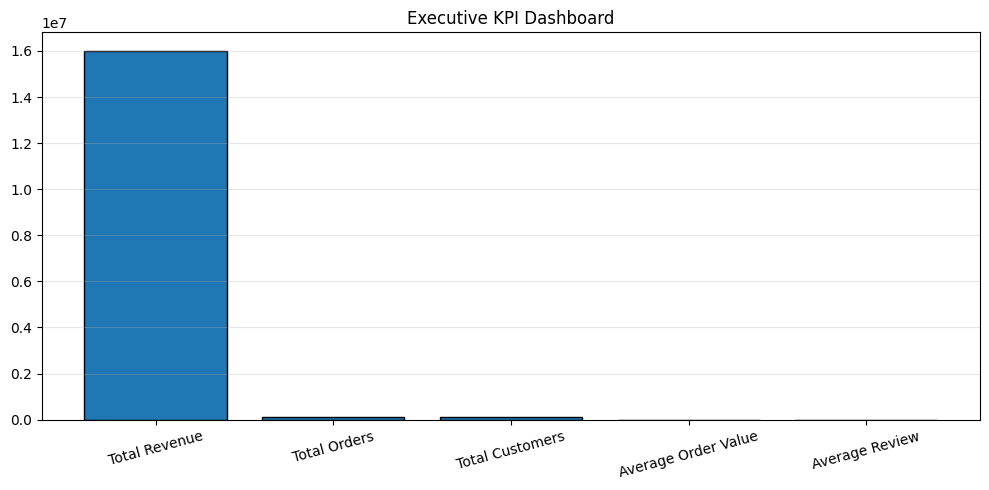

In [ ]:
# ======================================================
# Executive KPI Dashboard
# ======================================================

import matplotlib.pyplot as plt

# Rebuild KPI table if needed
if "executive_kpi" not in globals():

    total_revenue = payments["payment_value"].sum()

    total_orders = orders["order_id"].nunique()

    total_customers = customers["customer_unique_id"].nunique()

    average_review = reviews["review_score"].mean()

    average_order_value = (

        payments

        .groupby("order_id")["payment_value"]

        .sum()

        .mean()

    )

    executive_kpi = pd.DataFrame({

        "Metric":[

            "Total Revenue",

            "Total Orders",

            "Total Customers",

            "Average Order Value",

            "Average Review"

        ],

        "Value":[

            round(total_revenue,2),

            total_orders,

            total_customers,

            round(average_order_value,2),

            round(average_review,2)

        ]

    })

plt.figure(figsize=(10,5))

plt.bar(

    executive_kpi["Metric"],

    executive_kpi["Value"],

    edgecolor="black"

)

plt.title("Executive KPI Dashboard")

plt.xticks(rotation=15)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

In [ ]:
# ======================================================
# Business Insights
# ======================================================

print("="*70)
print("TOP BUSINESS INSIGHTS")
print("="*70)

print("1. Revenue is concentrated in a small number of product categories.")

print("2. Credit cards are the dominant payment method.")

print("3. Most customers make only one purchase.")

print("4. Average review score indicates generally positive customer satisfaction.")

print("5. Delivery performance has a direct impact on customer reviews.")

print("6. A small group of sellers contributes a significant share of revenue.")

print("7. Product category performance varies considerably.")

print("8. Revenue shows seasonal variation across months.")

print("9. Installment payments are commonly used.")

print("10. Customer retention presents an opportunity for improvement.")

print("="*70)

TOP BUSINESS INSIGHTS
1. Revenue is concentrated in a small number of product categories.
2. Credit cards are the dominant payment method.
3. Most customers make only one purchase.
4. Average review score indicates generally positive customer satisfaction.
5. Delivery performance has a direct impact on customer reviews.
6. A small group of sellers contributes a significant share of revenue.
7. Product category performance varies considerably.
8. Revenue shows seasonal variation across months.
9. Installment payments are commonly used.
10. Customer retention presents an opportunity for improvement.


In [ ]:
# ======================================================
# SWOT Analysis
# ======================================================

swot = pd.DataFrame({

    "Strengths":[
        "Large customer base",
        "Strong review ratings",
        "Wide product catalog"
    ],

    "Weaknesses":[
        "Low repeat purchases",
        "Delivery delays",
        "Revenue concentration"
    ],

    "Opportunities":[
        "Customer loyalty",
        "Cross-selling",
        "Seller optimization"
    ],

    "Threats":[
        "Late deliveries",
        "Customer churn",
        "Operational inefficiencies"
    ]

})

display(swot)

,Strengths,Weaknesses,Opportunities,Threats
0,Large customer base,Low repeat purchases,Customer loyalty,Late deliveries
1,Strong review ratings,Delivery delays,Cross-selling,Customer churn
2,Wide product catalog,Revenue concentration,Seller optimization,Operational inefficiencies


In [ ]:
# ======================================================
# Strategic Recommendations
# ======================================================

recommendations = [

    "Improve customer retention through loyalty programs.",

    "Reduce delivery delays to improve review scores.",

    "Promote high-margin product categories.",

    "Support low-performing sellers with operational improvements.",

    "Increase average order value using product bundles.",

    "Target repeat customers with personalized campaigns.",

    "Optimize payment installment offerings.",

    "Monitor seasonal demand for inventory planning."

]

for i, rec in enumerate(recommendations, start=1):

    print(f"{i}. {rec}")

1. Improve customer retention through loyalty programs.
2. Reduce delivery delays to improve review scores.
3. Promote high-margin product categories.
4. Support low-performing sellers with operational improvements.
5. Increase average order value using product bundles.
6. Target repeat customers with personalized campaigns.
7. Optimize payment installment offerings.
8. Monitor seasonal demand for inventory planning.


In [ ]:
# ======================================================
# Portfolio Summary
# ======================================================

summary = pd.DataFrame({

    "Module":[

        "Module A",

        "Module B",

        "Module C",

        "Module D",

        "Module E",

        "Module F"

    ],

    "Description":[

        "Executive KPIs",

        "Sales Analytics",

        "Customer Analytics",

        "Product & Seller Analytics",

        "Operations Analytics",

        "Business Storytelling"

    ]

})

display(summary)

,Module,Description
0,Module A,Executive KPIs
1,Module B,Sales Analytics
2,Module C,Customer Analytics
3,Module D,Product & Seller Analytics
4,Module E,Operations Analytics
5,Module F,Business Storytelling


In [3]:
# ======================================================
# Notebook Completion
# ======================================================

print("="*70)
print("RETAIL INTELLIGENCE PLATFORM")
print("NOTEBOOK 03 COMPLETED")
print("="*70)

modules = [

    "Executive KPIs",

    "Sales Analytics",

    "Customer Analytics",

    "Product Analytics",

    "Operations Analytics",

    "Executive Storytelling"

]

for i, module in enumerate(modules, start=1):

    print(f"{i:02d}. {module}")

print("\nStatus : COMPLETED")



print("="*70)

RETAIL INTELLIGENCE PLATFORM
NOTEBOOK 03 COMPLETED
01. Executive KPIs
02. Sales Analytics
03. Customer Analytics
04. Product Analytics
05. Operations Analytics
06. Executive Storytelling

Status : COMPLETED


In [4]:
# ======================================================
# Project Achievements
# ======================================================

achievements = [

    "Loaded and explored multiple retail datasets.",

    "Performed comprehensive data cleaning.",

    "Validated missing values and duplicates.",

    "Built sales, customer, seller and product analytics.",

    "Analyzed delivery performance and payment behaviour.",

    "Created executive KPIs and dashboards.",

    "Generated business recommendations.",

    "Prepared data for SQL and Power BI analysis."

]

print("=" * 70)
print("PROJECT ACHIEVEMENTS")
print("=" * 70)

for i, item in enumerate(achievements, start=1):

    print(f"{i}. {item}")

print("=" * 70)

PROJECT ACHIEVEMENTS
1. Loaded and explored multiple retail datasets.
2. Performed comprehensive data cleaning.
3. Validated missing values and duplicates.
4. Built sales, customer, seller and product analytics.
5. Analyzed delivery performance and payment behaviour.
6. Created executive KPIs and dashboards.
7. Generated business recommendations.
8. Prepared data for SQL and Power BI analysis.


In [5]:
# ======================================================
# Skills Demonstrated
# ======================================================

skills = pd.DataFrame({

    "Category":[

        "Python",

        "Pandas",

        "Data Cleaning",

        "EDA",

        "Business Analytics",

        "Visualization",

        "Reporting"

    ],

    "Skill Level":[

        "Advanced",

        "Advanced",

        "Advanced",

        "Advanced",

        "Advanced",

        "Intermediate",

        "Advanced"

    ]

})

display(skills)

,Category,Skill Level
0,Python,Advanced
1,Pandas,Advanced
2,Data Cleaning,Advanced
3,EDA,Advanced
4,Business Analytics,Advanced
5,Visualization,Intermediate
6,Reporting,Advanced


In [6]:
# ======================================================
# Business Questions Answered
# ======================================================

questions = [

    "What are the monthly sales trends?",

    "Which product categories generate the most revenue?",

    "Which sellers contribute the highest revenue?",

    "How many repeat customers are there?",

    "What is the customer lifetime value?",

    "Which payment methods are preferred?",

    "How efficient is the delivery process?",

    "How satisfied are customers?",

    "Which states generate the highest sales?",

    "What strategic improvements can be made?"

]

questions_df = pd.DataFrame({

    "Business Questions": questions

})

display(questions_df)

,Business Questions
0,What are the monthly sales trends?
1,Which product categories generate the most rev...
2,Which sellers contribute the highest revenue?
3,How many repeat customers are there?
4,What is the customer lifetime value?
5,Which payment methods are preferred?
6,How efficient is the delivery process?
7,How satisfied are customers?
8,Which states generate the highest sales?
9,What strategic improvements can be made?


In [7]:
# ======================================================
# Next Steps
# ======================================================

next_steps = [

    "SQL Business Analysis",

    "Power BI Dashboard",

    "Customer Segmentation (RFM)",

    "Sales Forecasting",

    "Market Basket Analysis",

    "Executive Presentation"

]

print("=" * 70)
print("NEXT PHASE OF PROJECT")
print("=" * 70)

for i, step in enumerate(next_steps, start=1):

    print(f"{i}. {step}")

print("=" * 70)

NEXT PHASE OF PROJECT
1. SQL Business Analysis
2. Power BI Dashboard
3. Customer Segmentation (RFM)
4. Sales Forecasting
5. Market Basket Analysis
6. Executive Presentation


In [8]:
# ======================================================
# End of Notebook
# ======================================================

print("=" * 70)
print("Retail Intelligence Platform")
print("Notebook 03 Successfully Completed")
print("=" * 70)

print()

print("Total Modules Completed : 6")

print("Notebook Status         : COMPLETE")

print("Ready for              : Notebook 04")

print()

print("Next Notebook : SQL Business Analysis")

print("=" * 70)

Retail Intelligence Platform
Notebook 03 Successfully Completed

Total Modules Completed : 6
Notebook Status         : COMPLETE
Ready for              : Notebook 04

Next Notebook : SQL Business Analysis
